# Final XGBoost Design: Jeonse-Equivalent Price Prediction with SHAP

This notebook reflects the post-meeting design decision:

- Use **XGBoost only** as the final model.
- Use monthly-rent rows by converting them into Jeonse-equivalent deposits.
- Compare feature sets rather than comparing multiple model families.
- Use SHAP to check whether spatial-derived variables meaningfully contribute to the final XGBoost prediction.

Target variable: `전세환산보증금(만원)`.

## 1. Final Experimental Design

The final report should not present Ridge, RandomForest, and XGBoost as competing final models. XGBoost is selected as the only final model family because it produced the best predictive accuracy in the previous model comparison.

The experiment is reframed as a feature-set comparison using the same XGBoost model:

| Experiment | Purpose | Features |
|---|---|---|
| `A_baseline_no_dong` | Basic baseline | apartment structure + contract time |
| `B_spatial_no_dong` | Spatial added-value without administrative location control | baseline + sea/park/school variables |
| `A_location_baseline` | Stronger baseline with administrative location control | baseline + `읍면동` |
| `B_location_spatial` | Conservative location-control spatial model | baseline + `읍면동` + spatial variables |

Interpretation rule:

- Primary predictive performance model: selected automatically by lowest test RMSE.
- Spatial added-value check: compare `A_baseline_no_dong` vs `B_spatial_no_dong`.
- Conservative location-control check: compare `A_location_baseline` vs `B_location_spatial`.
- SHAP interpretation: run SHAP for the best predictive model and, when different, also for `B_location_spatial`.
- If sea/park/school groups have meaningful SHAP importance, the spatial-variable argument is supported; otherwise, the paper should emphasize prediction performance more than spatial interpretation.

## 2. Colab Setup

Run this cell first. It clones the review branch when the dataset is not already present and installs only missing packages.

In [1]:
from pathlib import Path
import os
import sys
import subprocess
import importlib.util

REPO_URL = "https://github.com/hyeon03-sketch/IML-Final-project.git"
REPO_BRANCH = "codex/ml-project-review"
REPO_DIR = Path("IML-Final-project")
DATA_FILE = Path("IML_Final_dataset.xlsx")

if not DATA_FILE.exists() and Path("../IML_Final_dataset.xlsx").exists():
    os.chdir("..")

if not DATA_FILE.exists():
    if not REPO_DIR.exists():
        subprocess.check_call(["git", "clone", "--branch", REPO_BRANCH, "--single-branch", REPO_URL])
    os.chdir(REPO_DIR)

print("Working directory:", Path.cwd())
print("Dataset exists:", Path("IML_Final_dataset.xlsx").exists())

packages = {
    "pandas": "pandas",
    "numpy": "numpy",
    "openpyxl": "openpyxl",
    "sklearn": "scikit-learn",
    "xgboost": "xgboost",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "shap": "shap",
}
missing = [pip_name for import_name, pip_name in packages.items() if importlib.util.find_spec(import_name) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
    print("Installed:", missing)
else:
    print("All required packages are already installed.")

Working directory: /content/IML-Final-project
Dataset exists: True
All required packages are already installed.


## 3. Imports and Korean Font Setup

In [2]:
import warnings
from pathlib import Path
import os
import subprocess

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import shap

from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV, GroupShuffleSplit, KFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
RND = 42
DATA_PATH = Path("IML_Final_dataset.xlsx")
SHEET_NAME = "최종데이터셋_모델용"
TARGET = "전세환산보증금(만원)"
CONVERSION_RATE = 0.065
OUT_DIR = Path("outputs_final_xgboost_shap")
OUT_DIR.mkdir(exist_ok=True)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)


def setup_korean_font():
    """Set a Korean font without leaving Matplotlib's font cache in a stale state."""
    candidate_paths = [
        Path("/usr/share/fonts/truetype/nanum/NanumGothic.ttf"),
        Path("/usr/share/fonts/truetype/nanum/NanumBarunGothic.ttf"),
        Path("/System/Library/Fonts/AppleSDGothicNeo.ttc"),
        Path("/Library/Fonts/AppleGothic.ttf"),
        Path("C:/Windows/Fonts/malgun.ttf"),
    ]

    if not any(p.exists() for p in candidate_paths):
        try:
            subprocess.check_call(["apt-get", "update", "-qq"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            subprocess.check_call(["apt-get", "install", "-y", "fonts-nanum"], stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
        except Exception as exc:
            print("Korean font installation skipped:", exc)

    for cache_file in Path.home().glob(".cache/matplotlib/fontlist*"):
        try:
            cache_file.unlink()
        except Exception:
            pass

    font_paths = [p for p in candidate_paths if p.exists()]
    for font_path in font_paths:
        try:
            fm.fontManager.addfont(str(font_path))
        except Exception:
            pass

    try:
        fm._load_fontmanager(try_read_cache=False)
    except Exception:
        pass

    for font_path in font_paths:
        try:
            font_name = fm.FontProperties(fname=str(font_path)).get_name()
            mpl.rcParams["font.family"] = [font_name]
            mpl.rcParams["font.sans-serif"] = [font_name]
            mpl.rcParams["axes.unicode_minus"] = False
            sns.set_theme(font=font_name)
            print("Font:", font_name)
            print("Font file:", font_path)
            return font_name
        except Exception:
            continue

    mpl.rcParams["axes.unicode_minus"] = False
    print("Font: default. Korean labels may not render correctly.")
    return "default"

font_used = setup_korean_font()

Font: NanumGothic
Font file: /usr/share/fonts/truetype/nanum/NanumGothic.ttf


## 4. Load Data and Create Jeonse-Equivalent Target

Monthly-rent rows are retained by converting monthly rent into a Jeonse-equivalent deposit:

$$
\text{Jeonse-equivalent deposit} = \text{Deposit} + \frac{\text{Monthly rent} \times 12}{\text{Conversion rate}}
$$

The default conversion rate is 6.5% (`0.065`). Deposit and monthly rent are both measured in 10,000 KRW units, so the converted target is also in 10,000 KRW units.

In [3]:
def make_jeonse_equivalent_target(data, conversion_rate=CONVERSION_RATE):
    out = data.copy()
    deposit = pd.to_numeric(out["보증금(만원)"], errors="coerce")
    monthly_rent = pd.to_numeric(out["월세금(만원)"], errors="coerce").fillna(0)
    lease_type = out["전월세구분"].astype(str).str.strip()

    target = deposit.astype(float).copy()
    monthly_mask = lease_type.eq("월세")
    target.loc[monthly_mask] = deposit.loc[monthly_mask] + monthly_rent.loc[monthly_mask] * 12.0 / conversion_rate
    out[TARGET] = target
    return out


def first_mode(series):
    modes = series.mode(dropna=False)
    if len(modes) == 0:
        return np.nan
    return modes.iloc[0]


def harmonize_dong_level_features(data, feature_cols, group_col="읍면동"):
    """Dong-derived variables should be constant within the same dong.

    When the raw sheet contains conflicting values within a dong, the modal value is used.
    This keeps administrative-dong-level spatial features logically consistent.
    """
    out = data.copy()
    report_rows = []
    for col in feature_cols:
        if col not in out.columns:
            continue
        unique_by_dong = out.groupby(group_col)[col].nunique(dropna=False)
        inconsistent_dongs = unique_by_dong[unique_by_dong > 1].index.tolist()
        before = out[col].copy()
        modal_values = out.groupby(group_col)[col].transform(first_mode)
        out[col] = modal_values
        changed = int((before.astype(str) != out[col].astype(str)).sum())
        report_rows.append({
            "feature": col,
            "inconsistent_dong_count_before": len(inconsistent_dongs),
            "rows_changed_by_harmonization": changed,
            "max_unique_values_within_dong_after": int(out.groupby(group_col)[col].nunique(dropna=False).max()),
        })
    return out, pd.DataFrame(report_rows)

DONG_LEVEL_HARMONIZATION_COLS = [
    "바다여부",
    "공원여부",
    "공원수",
    "최대공원면적(㎡)",
    "총공원면적(㎡)",
    "동_초등학교수",
    "동_중학교수",
    "동_고등학교수",
    "동_총학교수",
    "동_초중고모두있음여부",
]

raw = pd.read_excel(DATA_PATH, sheet_name=SHEET_NAME)
df = make_jeonse_equivalent_target(raw, CONVERSION_RATE)
df = df[df[TARGET].notna() & df[TARGET].gt(0)].copy()
df, dong_harmonization_report = harmonize_dong_level_features(df, DONG_LEVEL_HARMONIZATION_COLS)

print("Original rows:", len(raw))
print("Modeling rows:", len(df))
print("Jeonse rows:", int(df["전월세구분"].eq("전세").sum()))
print("Monthly-rent rows converted:", int(df["전월세구분"].eq("월세").sum()))
print("Dong count:", df["읍면동"].nunique())
print("Contract years:", sorted(df["계약연도"].dropna().unique()))
print("Missing cells in selected raw data:", int(df.isna().sum().sum()))

print("Dong-level feature harmonization report")
display(dong_harmonization_report)
dong_harmonization_report.to_csv(OUT_DIR / "dong_level_harmonization_report.csv", index=False, encoding="utf-8-sig")

display(df[["전월세구분", "보증금(만원)", "월세금(만원)", TARGET]].head(10))
display(df[[TARGET, "전용면적(㎡)", "층", "건물연령(계약기준)", "계약연도", "계약월"]].describe())

Original rows: 4470
Modeling rows: 4470
Jeonse rows: 2486
Monthly-rent rows converted: 1984
Dong count: 26
Contract years: [np.int64(2025), np.int64(2026)]
Missing cells in selected raw data: 0
Dong-level feature harmonization report


,feature,inconsistent_dong_count_before,rows_changed_by_harmonization,max_unique_values_within_dong_after
0,바다여부,0,0,1
1,공원여부,0,0,1
2,공원수,0,0,1
3,최대공원면적(㎡),0,0,1
4,총공원면적(㎡),0,0,1
5,동_초등학교수,8,79,1
6,동_중학교수,0,0,1
7,동_고등학교수,0,0,1
8,동_총학교수,8,79,1
9,동_초중고모두있음여부,0,0,1


,전월세구분,보증금(만원),월세금(만원),전세환산보증금(만원)
0,월세,2000,60,13076.923077
1,월세,1562,7,2854.307692
2,월세,1476,7,2768.307692
3,월세,1476,7,2768.307692
4,전세,14000,0,14000.000000
5,월세,1500,50,10730.769231
6,월세,562,10,2408.153846
7,전세,10000,0,10000.000000
8,월세,4392,20,8084.307692
9,월세,1562,7,2854.307692


,전세환산보증금(만원),전용면적(㎡),층,건물연령(계약기준),계약연도,계약월
count,4470.000000,4470.000000,4470.000000,4470.000000,4470.000000,4470.000000
mean,15707.247858,74.122807,11.143400,14.983669,2025.267785,6.545414
std,6841.290045,19.740472,7.377114,12.009225,0.442855,3.637473
min,1416.692308,16.900000,1.000000,0.000000,2025.000000,1.000000
25%,9730.769231,59.940000,5.000000,2.000000,2025.000000,3.000000
50%,15846.153846,84.515000,10.000000,13.000000,2025.000000,7.000000
75%,20000.000000,84.959900,16.000000,26.000000,2026.000000,10.000000
max,46153.846154,197.681200,47.000000,45.000000,2026.000000,12.000000


## 5. Target Distribution

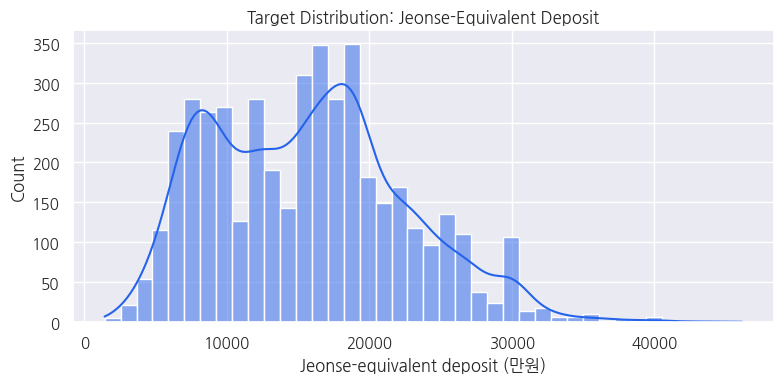

Target mean: 15707.25
Target median: 15846.15
Target std: 6841.29


In [4]:
plt.figure(figsize=(8, 4))
sns.histplot(df[TARGET], bins=40, kde=True, color="#2563eb")
plt.title("Target Distribution: Jeonse-Equivalent Deposit")
plt.xlabel("Jeonse-equivalent deposit (만원)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUT_DIR / "target_distribution.png", dpi=150)
plt.show()

print("Target mean:", round(df[TARGET].mean(), 2))
print("Target median:", round(df[TARGET].median(), 2))
print("Target std:", round(df[TARGET].std(), 2))

## 6. Feature Sets and Dong-Level Collinearity Check

Spatial variables are administrative-dong-level variables. If they are perfectly determined by `읍면동`, then including both `읍면동` one-hot variables and spatial variables can split attribution between them. This is not direct target leakage, but it matters for interpretation.

In [5]:
BASE_FEATURES = ["전용면적(㎡)", "층", "건물연령(계약기준)", "계약연도", "계약월"]
DONG_FEATURE = ["읍면동"]
SPATIAL_FEATURES = [
    "바다여부",
    "공원여부",
    "공원수",
    "최대공원면적(㎡)",
    "동_초등학교수",
    "동_중학교수",
    "동_고등학교수",
    "동_초중고모두있음여부",
]

# Removed from the default design because of clear redundancy or high overlap:
# - 동_총학교수 = 동_초등학교수 + 동_중학교수 + 동_고등학교수
# - 총공원면적(㎡) overlaps strongly with other park area/count variables in previous VIF checks.
EXCLUDED_SPATIAL_FEATURES = ["동_총학교수", "총공원면적(㎡)"]

FEATURE_GROUPS = {
    "A_baseline_no_dong": BASE_FEATURES,
    "B_spatial_no_dong": BASE_FEATURES + SPATIAL_FEATURES,
    "A_location_baseline": BASE_FEATURES + DONG_FEATURE,
    "B_location_spatial": BASE_FEATURES + DONG_FEATURE + SPATIAL_FEATURES,
}

BINARY_COLS = {"바다여부", "공원여부", "동_초중고모두있음여부"}
CATEGORICAL_COLS = {"읍면동"}

print("Feature groups")
for name, cols in FEATURE_GROUPS.items():
    print(name, len(cols), cols)

# Check whether spatial variables are constant within each dong.
dong_level_rows = []
for col in SPATIAL_FEATURES + EXCLUDED_SPATIAL_FEATURES:
    max_unique_by_dong = int(df.groupby("읍면동")[col].nunique(dropna=False).max())
    dong_level_rows.append({
        "feature": col,
        "max_unique_values_within_dong": max_unique_by_dong,
        "fully_determined_by_dong": max_unique_by_dong == 1,
    })
dong_level_check = pd.DataFrame(dong_level_rows)
display(dong_level_check)
dong_level_check.to_csv(OUT_DIR / "dong_level_spatial_check.csv", index=False, encoding="utf-8-sig")

Feature groups
A_baseline_no_dong 5 ['전용면적(㎡)', '층', '건물연령(계약기준)', '계약연도', '계약월']
B_spatial_no_dong 13 ['전용면적(㎡)', '층', '건물연령(계약기준)', '계약연도', '계약월', '바다여부', '공원여부', '공원수', '최대공원면적(㎡)', '동_초등학교수', '동_중학교수', '동_고등학교수', '동_초중고모두있음여부']
A_location_baseline 6 ['전용면적(㎡)', '층', '건물연령(계약기준)', '계약연도', '계약월', '읍면동']
B_location_spatial 14 ['전용면적(㎡)', '층', '건물연령(계약기준)', '계약연도', '계약월', '읍면동', '바다여부', '공원여부', '공원수', '최대공원면적(㎡)', '동_초등학교수', '동_중학교수', '동_고등학교수', '동_초중고모두있음여부']


,feature,max_unique_values_within_dong,fully_determined_by_dong
0,바다여부,1,True
1,공원여부,1,True
2,공원수,1,True
3,최대공원면적(㎡),1,True
4,동_초등학교수,1,True
5,동_중학교수,1,True
6,동_고등학교수,1,True
7,동_초중고모두있음여부,1,True
8,동_총학교수,1,True
9,총공원면적(㎡),1,True


## 7. XGBoost Pipeline and Metrics

No scaler is used because XGBoost is tree-based and does not require feature scaling. Categorical `읍면동` is one-hot encoded only in the location-control settings.

In [6]:
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def split_feature_types(cols):
    categorical = [c for c in cols if c in CATEGORICAL_COLS]
    binary = [c for c in cols if c in BINARY_COLS]
    numeric = [c for c in cols if c not in set(categorical + binary)]
    return numeric, categorical, binary


def make_preprocessor(cols):
    numeric, categorical, binary = split_feature_types(cols)
    transformers = []
    pass_cols = numeric + binary
    if pass_cols:
        transformers.append(("pass", "passthrough", pass_cols))
    if categorical:
        transformers.append(("cat", make_one_hot_encoder(), categorical))
    return ColumnTransformer(transformers=transformers, remainder="drop")


def make_xgboost():
    return XGBRegressor(
        objective="reg:squarederror",
        tree_method="hist",
        random_state=RND,
        n_jobs=-1,
        importance_type="gain",
    )

XGB_PARAM_GRID = {
    "model__n_estimators": [300, 600],
    "model__max_depth": [4, 6],
    "model__learning_rate": [0.05, 0.1],
    "model__subsample": [0.9],
    "model__colsample_bytree": [0.9],
}


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


def mape_pct(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = y_true > 0
    return float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100)


def evaluate_predictions(y_true, pred):
    return {
        "test_rmse": rmse(y_true, pred),
        "test_mae": float(mean_absolute_error(y_true, pred)),
        "test_mape_pct": mape_pct(y_true, pred),
        "test_r2": float(r2_score(y_true, pred)),
        "mae_pct_of_mean_target": float(mean_absolute_error(y_true, pred) / y_true.mean() * 100),
    }


def fit_xgb_grid(data, group_name, cols, train_idx, test_idx):
    X = data[cols].copy()
    y = data[TARGET].copy()
    X_train, X_test = X.loc[train_idx], X.loc[test_idx]
    y_train, y_test = y.loc[train_idx], y.loc[test_idx]

    pipe = Pipeline([
        ("pre", make_preprocessor(cols)),
        ("model", make_xgboost()),
    ])
    search = GridSearchCV(
        pipe,
        param_grid=XGB_PARAM_GRID,
        scoring="neg_root_mean_squared_error",
        cv=KFold(n_splits=5, shuffle=True, random_state=RND),
        n_jobs=-1,
        verbose=0,
    )
    search.fit(X_train, y_train)
    pred = search.predict(X_test)
    metrics = evaluate_predictions(y_test, pred)
    metrics.update({
        "experiment": group_name,
        "model": "XGBoost",
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "n_features_raw": len(cols),
        "cv_rmse": float(-search.best_score_),
        "best_params": search.best_params_,
    })
    fitted = {
        "estimator": search.best_estimator_,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "pred": pred,
        "best_params": search.best_params_,
    }
    return metrics, fitted

## 8. Main XGBoost Feature-Set Experiments

In [7]:
train_idx, test_idx = train_test_split(df.index, test_size=0.2, random_state=RND)

rows = []
fitted = {}
for group_name, cols in FEATURE_GROUPS.items():
    print("Running", group_name)
    metrics, bundle = fit_xgb_grid(df, group_name, cols, train_idx, test_idx)
    rows.append(metrics)
    fitted[group_name] = bundle
    print(
        f"  RMSE={metrics['test_rmse']:.2f}, MAE={metrics['test_mae']:.2f}, "
        f"MAPE={metrics['test_mape_pct']:.2f}%, R2={metrics['test_r2']:.4f}"
    )

results = pd.DataFrame(rows).sort_values("test_rmse")
display(results[[
    "experiment", "model", "n_train", "n_test", "n_features_raw", "cv_rmse",
    "test_rmse", "test_mae", "test_mape_pct", "test_r2", "mae_pct_of_mean_target", "best_params"
]])
results.to_csv(OUT_DIR / "xgboost_feature_set_results.csv", index=False, encoding="utf-8-sig")

Running A_baseline_no_dong
  RMSE=2308.27, MAE=1603.66, MAPE=12.00%, R2=0.8883
Running B_spatial_no_dong
  RMSE=2204.22, MAE=1505.42, MAPE=11.19%, R2=0.8981
Running A_location_baseline
  RMSE=2216.95, MAE=1518.12, MAPE=11.40%, R2=0.8969
Running B_location_spatial
  RMSE=2208.91, MAE=1515.95, MAPE=11.39%, R2=0.8977


,experiment,model,n_train,n_test,n_features_raw,cv_rmse,test_rmse,test_mae,test_mape_pct,test_r2,mae_pct_of_mean_target,best_params
1,B_spatial_no_dong,XGBoost,3576,894,13,2336.333543,2204.215866,1505.422029,11.189471,0.898111,9.692717,"{'model__colsample_bytree': 0.9, 'model__learn..."
3,B_location_spatial,XGBoost,3576,894,14,2350.609468,2208.909126,1515.952854,11.387839,0.897677,9.760520,"{'model__colsample_bytree': 0.9, 'model__learn..."
2,A_location_baseline,XGBoost,3576,894,6,2346.311939,2216.952419,1518.121552,11.401982,0.896930,9.774483,"{'model__colsample_bytree': 0.9, 'model__learn..."
0,A_baseline_no_dong,XGBoost,3576,894,5,2502.248649,2308.274982,1603.657977,11.996733,0.888264,10.325213,"{'model__colsample_bytree': 0.9, 'model__learn..."


## 9. A/B Comparison Tables

These comparisons answer two different questions.

1. No-dong comparison: Do spatial variables improve the baseline model?
2. Location-control comparison: Do spatial variables add value after administrative dong is already included?

In [8]:
def compare_delta(left, right):
    left_row = results[results["experiment"].eq(left)].iloc[0]
    right_row = results[results["experiment"].eq(right)].iloc[0]
    out = pd.DataFrame([{
        "comparison": f"{right} - {left}",
        "delta_rmse": right_row["test_rmse"] - left_row["test_rmse"],
        "delta_mae": right_row["test_mae"] - left_row["test_mae"],
        "delta_mape_pct": right_row["test_mape_pct"] - left_row["test_mape_pct"],
        "delta_r2": right_row["test_r2"] - left_row["test_r2"],
    }])
    out["rmse_improved"] = out["delta_rmse"] < 0
    out["mape_improved"] = out["delta_mape_pct"] < 0
    out["r2_improved"] = out["delta_r2"] > 0
    return out

comparison = pd.concat([
    compare_delta("A_baseline_no_dong", "B_spatial_no_dong"),
    compare_delta("A_location_baseline", "B_location_spatial"),
], ignore_index=True)

display(comparison)
comparison.to_csv(OUT_DIR / "xgboost_ab_comparison.csv", index=False, encoding="utf-8-sig")

best_row = results.sort_values("test_rmse").iloc[0]
BEST_RMSE_GROUP = best_row["experiment"]
LOCATION_CONTROL_GROUP = "B_location_spatial"

model_selection_summary = pd.DataFrame([
    {
        "role": "primary_prediction_model_lowest_rmse",
        "experiment": BEST_RMSE_GROUP,
        "test_rmse": best_row["test_rmse"],
        "test_mae": best_row["test_mae"],
        "test_mape_pct": best_row["test_mape_pct"],
        "test_r2": best_row["test_r2"],
    },
    {
        "role": "conservative_location_control_model",
        "experiment": LOCATION_CONTROL_GROUP,
        "test_rmse": results.loc[results["experiment"].eq(LOCATION_CONTROL_GROUP), "test_rmse"].iloc[0],
        "test_mae": results.loc[results["experiment"].eq(LOCATION_CONTROL_GROUP), "test_mae"].iloc[0],
        "test_mape_pct": results.loc[results["experiment"].eq(LOCATION_CONTROL_GROUP), "test_mape_pct"].iloc[0],
        "test_r2": results.loc[results["experiment"].eq(LOCATION_CONTROL_GROUP), "test_r2"].iloc[0],
    },
])

print("Best XGBoost setting by test RMSE:", BEST_RMSE_GROUP)
display(model_selection_summary)
model_selection_summary.to_csv(OUT_DIR / "model_selection_summary.csv", index=False, encoding="utf-8-sig")

,comparison,delta_rmse,delta_mae,delta_mape_pct,delta_r2,rmse_improved,mape_improved,r2_improved
0,B_spatial_no_dong - A_baseline_no_dong,-104.059116,-98.235948,-0.807262,0.009847,True,True,True
1,B_location_spatial - A_location_baseline,-8.043293,-2.168699,-0.014143,0.000747,True,True,True


Best XGBoost setting by test RMSE: B_spatial_no_dong


,role,experiment,test_rmse,test_mae,test_mape_pct,test_r2
0,primary_prediction_model_lowest_rmse,B_spatial_no_dong,2204.215866,1505.422029,11.189471,0.898111
1,conservative_location_control_model,B_location_spatial,2208.909126,1515.952854,11.387839,0.897677


## 10. Prediction vs Actual for Selected Models

The primary prediction model is selected automatically by lowest test RMSE. The conservative location-control model is also plotted when it is different from the primary prediction model.

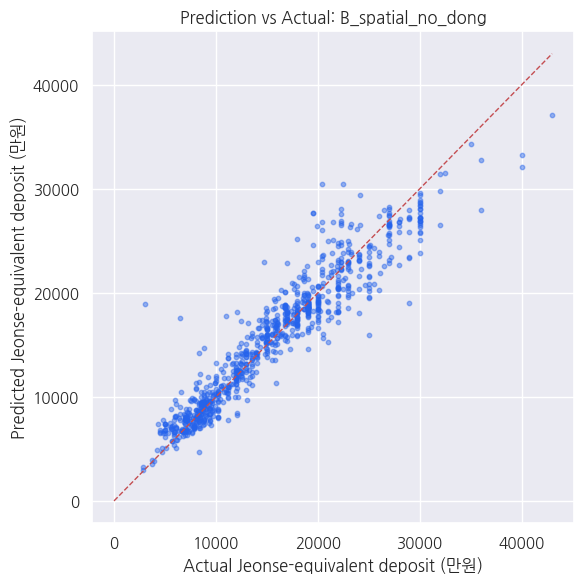

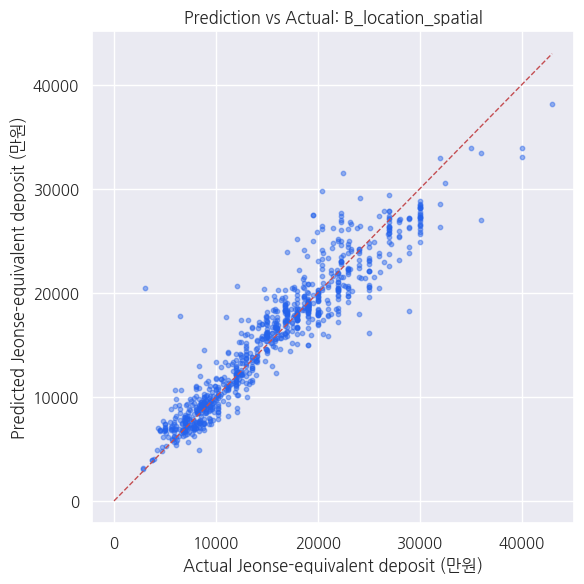

In [9]:
PLOT_GROUPS = [BEST_RMSE_GROUP]
if LOCATION_CONTROL_GROUP not in PLOT_GROUPS:
    PLOT_GROUPS.append(LOCATION_CONTROL_GROUP)

for group_name in PLOT_GROUPS:
    bundle = fitted[group_name]
    plt.figure(figsize=(6, 6))
    plt.scatter(bundle["y_test"], bundle["pred"], s=10, alpha=0.45, color="#2563eb")
    lim = max(bundle["y_test"].max(), np.max(bundle["pred"]))
    plt.plot([0, lim], [0, lim], "r--", lw=1)
    plt.xlabel("Actual Jeonse-equivalent deposit (만원)")
    plt.ylabel("Predicted Jeonse-equivalent deposit (만원)")
    plt.title(f"Prediction vs Actual: {group_name}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"prediction_vs_actual_{group_name}.png", dpi=150)
    plt.show()

## 11. SHAP Interpretation

SHAP is used to determine whether spatial-derived variables are important in XGBoost predictions. SHAP is computed for the primary prediction model and, if different, for the conservative `B_location_spatial` model.

Important correction: `건물연령(계약기준)` is a housing-structure variable, not a contract-time variable, even though its Korean name contains `계약기준`.


SHAP group: B_spatial_no_dong
Spatial SHAP share (sea + park + school): 19.24%


,feature,mean_abs_shap,feature_group
2,pass__건물연령(계약기준),3857.360840,housing_structure
0,pass__전용면적(㎡),2502.539795,housing_structure
7,pass__동_초등학교수,862.126892,school
1,pass__층,338.379028,housing_structure
5,pass__공원수,214.100372,park
9,pass__동_고등학교수,191.351685,school
6,pass__최대공원면적(㎡),185.314041,park
4,pass__계약월,160.415894,contract_time
8,pass__동_중학교수,119.555847,school
10,pass__바다여부,55.462189,sea


,feature_group,mean_abs_shap,share_pct
1,housing_structure,6698.279785,78.495872
3,school,1186.002808,13.898542
2,park,400.413300,4.692368
0,contract_time,193.130585,2.263261
4,sea,55.462189,0.649951


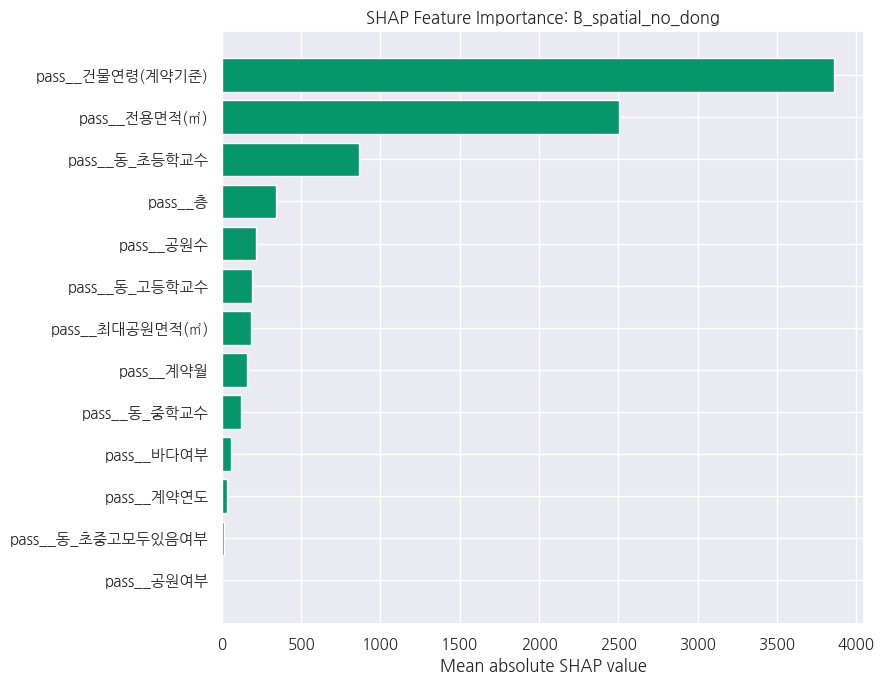

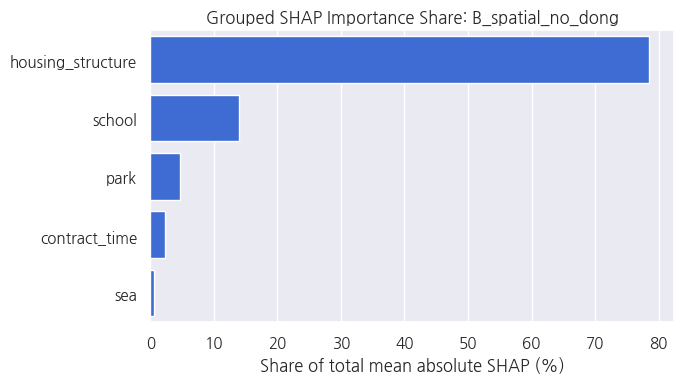


SHAP group: B_location_spatial
Spatial SHAP share (sea + park + school): 17.24%


,feature,mean_abs_shap,feature_group
2,pass__건물연령(계약기준),3763.476318,housing_structure
0,pass__전용면적(㎡),2642.890869,housing_structure
7,pass__동_초등학교수,856.736633,school
1,pass__층,316.680878,housing_structure
5,pass__공원수,267.581787,park
6,pass__최대공원면적(㎡),180.179382,park
4,pass__계약월,141.607925,contract_time
9,pass__동_고등학교수,100.290375,school
8,pass__동_중학교수,86.212250,school
34,cat__읍면동_흥해읍 이인리,74.219627,dong_location


,feature_group,mean_abs_shap,share_pct
2,housing_structure,6723.047852,75.511887
4,school,1050.397705,11.797850
1,dong_location,479.618835,5.386980
3,park,447.761169,5.029161
0,contract_time,165.488159,1.858729
5,sea,36.984787,0.415405


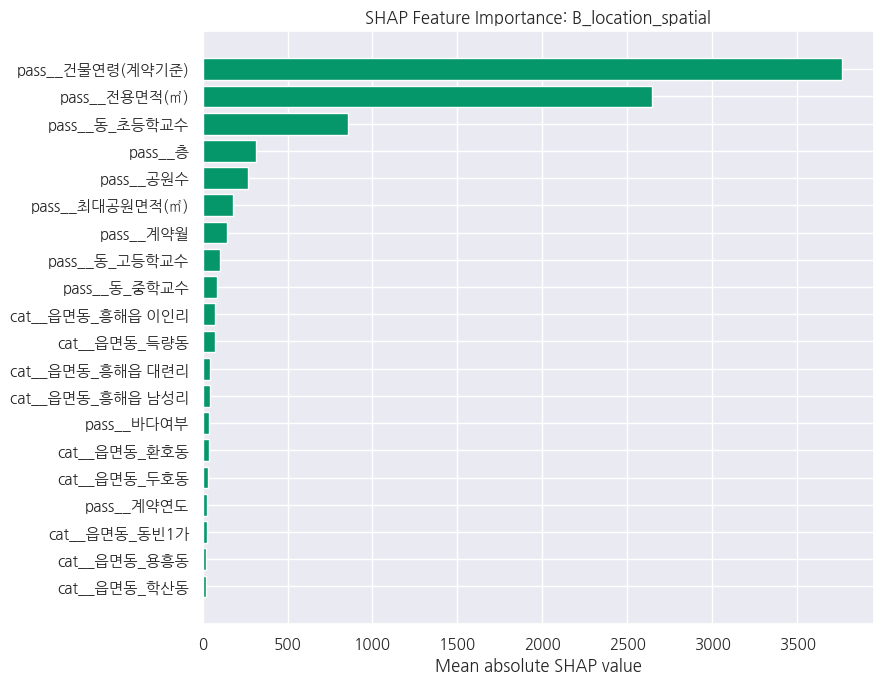

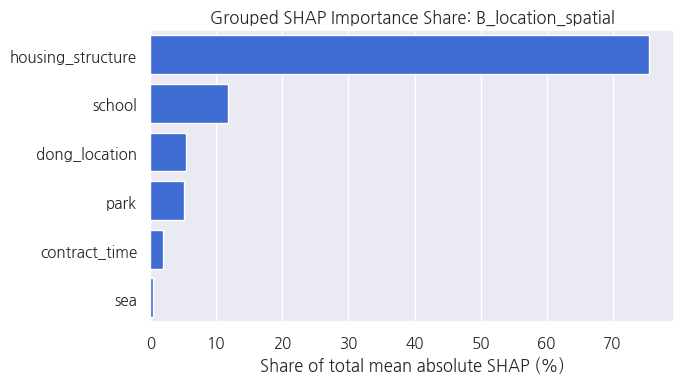

,experiment,spatial_share_pct
0,B_spatial_no_dong,19.240860
1,B_location_spatial,17.242416


In [10]:
SHAP_SAMPLE_SIZE = 800


def feature_group(feature_name):
    name = str(feature_name)
    clean = name.split("__", 1)[-1]

    if clean.startswith("읍면동_") or "읍면동" in clean:
        return "dong_location"
    if "바다" in clean:
        return "sea"
    if "공원" in clean:
        return "park"
    if "학교" in clean or "초중고" in clean:
        return "school"
    if "전용면적" in clean or clean == "층" or "건물연령" in clean:
        return "housing_structure"
    if clean in {"계약연도", "계약월"}:
        return "contract_time"
    return "other"


def compute_shap_for_group(group_name):
    bundle = fitted[group_name]
    pipe = bundle["estimator"]
    pre = pipe.named_steps["pre"]
    model = pipe.named_steps["model"]

    X_test = bundle["X_test"].copy()
    if len(X_test) > SHAP_SAMPLE_SIZE:
        X_shap = X_test.sample(SHAP_SAMPLE_SIZE, random_state=RND)
    else:
        X_shap = X_test

    X_shap_transformed = pre.transform(X_shap)
    feature_names = pre.get_feature_names_out()

    explainer = shap.TreeExplainer(model)
    raw_shap_values = explainer.shap_values(X_shap_transformed)
    shap_values = raw_shap_values.values if hasattr(raw_shap_values, "values") else raw_shap_values

    shap_importance = pd.DataFrame({
        "feature": feature_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    }).sort_values("mean_abs_shap", ascending=False)
    shap_importance["feature_group"] = shap_importance["feature"].map(feature_group)

    group_shap = (
        shap_importance.groupby("feature_group", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )
    group_shap["share_pct"] = group_shap["mean_abs_shap"] / group_shap["mean_abs_shap"].sum() * 100

    spatial_groups = {"sea", "park", "school"}
    spatial_share = group_shap[group_shap["feature_group"].isin(spatial_groups)]["share_pct"].sum()

    shap_importance.to_csv(OUT_DIR / f"shap_feature_importance_{group_name}.csv", index=False, encoding="utf-8-sig")
    group_shap.to_csv(OUT_DIR / f"shap_group_importance_{group_name}.csv", index=False, encoding="utf-8-sig")

    print(f"\nSHAP group: {group_name}")
    print(f"Spatial SHAP share (sea + park + school): {spatial_share:.2f}%")
    display(shap_importance.head(30))
    display(group_shap)

    plt.figure(figsize=(9, 7))
    top = shap_importance.head(20).iloc[::-1]
    plt.barh(top["feature"], top["mean_abs_shap"], color="#059669")
    plt.title(f"SHAP Feature Importance: {group_name}")
    plt.xlabel("Mean absolute SHAP value")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"shap_top20_features_{group_name}.png", dpi=150)
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.barplot(data=group_shap, y="feature_group", x="share_pct", color="#2563eb")
    plt.title(f"Grouped SHAP Importance Share: {group_name}")
    plt.xlabel("Share of total mean absolute SHAP (%)")
    plt.ylabel("")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"shap_group_importance_{group_name}.png", dpi=150)
    plt.show()

    return {
        "group_name": group_name,
        "X_transformed": X_shap_transformed,
        "feature_names": feature_names,
        "shap_values": shap_values,
        "feature_importance": shap_importance,
        "group_importance": group_shap,
        "spatial_share_pct": spatial_share,
    }

SHAP_GROUPS = [BEST_RMSE_GROUP]
if LOCATION_CONTROL_GROUP not in SHAP_GROUPS:
    SHAP_GROUPS.append(LOCATION_CONTROL_GROUP)

shap_artifacts = {group_name: compute_shap_for_group(group_name) for group_name in SHAP_GROUPS}

shap_summary_rows = []
for group_name, artifact in shap_artifacts.items():
    shap_summary_rows.append({
        "experiment": group_name,
        "spatial_share_pct": artifact["spatial_share_pct"],
    })
shap_summary = pd.DataFrame(shap_summary_rows)
display(shap_summary)
shap_summary.to_csv(OUT_DIR / "shap_spatial_share_summary.csv", index=False, encoding="utf-8-sig")

## 12. SHAP Summary Plot

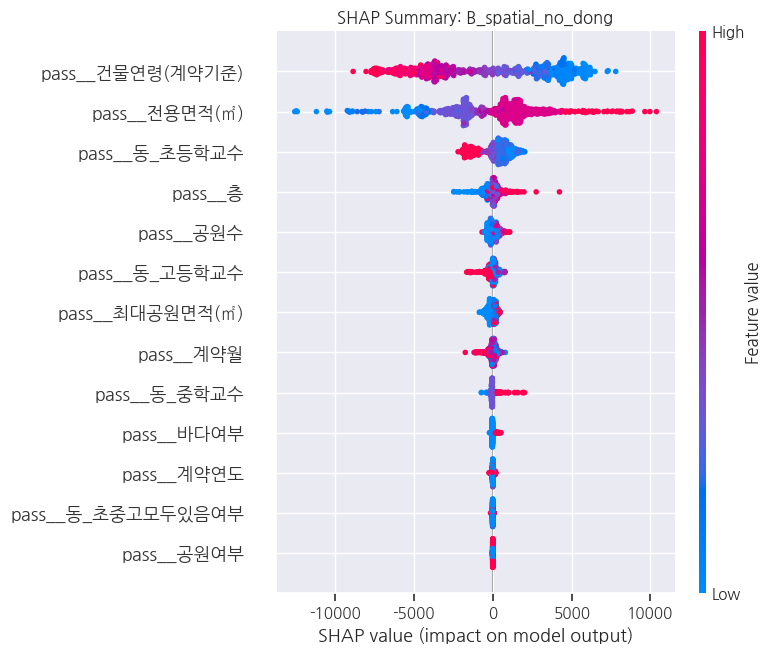

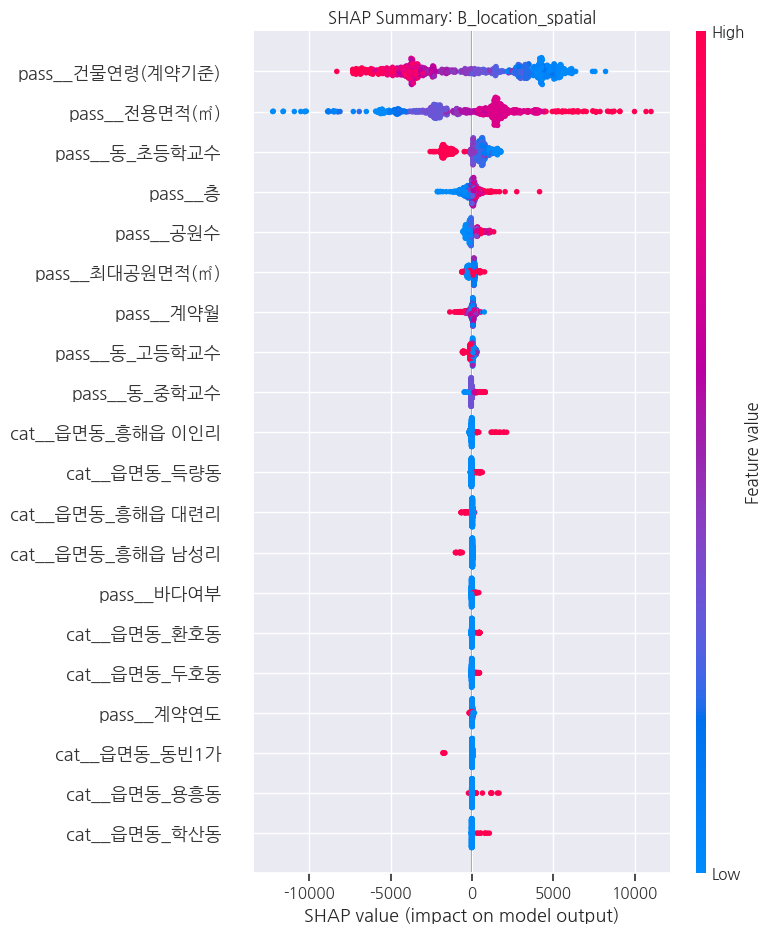

In [11]:
# SHAP summary plots can be visually dense, but they are useful for checking direction and magnitude.
for group_name, artifact in shap_artifacts.items():
    shap.summary_plot(
        artifact["shap_values"],
        artifact["X_transformed"],
        feature_names=artifact["feature_names"],
        show=False,
        max_display=20,
    )
    plt.title(f"SHAP Summary: {group_name}")
    plt.tight_layout()
    plt.savefig(OUT_DIR / f"shap_summary_top20_{group_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 13. Robustness Validation

This section checks whether the XGBoost feature-set comparisons are maintained under stricter splits.

Two comparisons are reported:

1. `B_spatial_no_dong - A_baseline_no_dong`: main spatial added-value without administrative dong control.
2. `B_location_spatial - A_location_baseline`: conservative check after administrative dong control.

The second comparison can be weaker because most spatial variables are dong-level variables and can overlap with `읍면동` one-hot information.

In [12]:
RUN_STRICT_VALIDATION = True
STRICT_COMPARISONS = [
    ("A_baseline_no_dong", "B_spatial_no_dong"),
    ("A_location_baseline", "B_location_spatial"),
]
STRICT_GROUPS = []
for left, right in STRICT_COMPARISONS:
    for group in [left, right]:
        if group not in STRICT_GROUPS:
            STRICT_GROUPS.append(group)


def run_strict_holdout(validation_name, train_idx, test_idx):
    rows = []
    for group_name in STRICT_GROUPS:
        print("Strict", validation_name, group_name)
        metrics, _ = fit_xgb_grid(df, group_name, FEATURE_GROUPS[group_name], train_idx, test_idx)
        metrics["validation"] = validation_name
        rows.append(metrics)
    return rows


def make_strict_delta(strict_results):
    delta_rows = []
    for validation_name in strict_results["validation"].unique():
        sub = strict_results[strict_results["validation"].eq(validation_name)]
        for left, right in STRICT_COMPARISONS:
            left_row = sub[sub["experiment"].eq(left)].iloc[0]
            right_row = sub[sub["experiment"].eq(right)].iloc[0]
            delta_rows.append({
                "validation": validation_name,
                "comparison": f"{right} - {left}",
                "delta_rmse": right_row["test_rmse"] - left_row["test_rmse"],
                "delta_mae": right_row["test_mae"] - left_row["test_mae"],
                "delta_mape_pct": right_row["test_mape_pct"] - left_row["test_mape_pct"],
                "delta_r2": right_row["test_r2"] - left_row["test_r2"],
            })
    delta = pd.DataFrame(delta_rows)
    delta["spatial_improves_rmse"] = delta["delta_rmse"] < 0
    delta["spatial_improves_mape"] = delta["delta_mape_pct"] < 0
    delta["spatial_improves_r2"] = delta["delta_r2"] > 0
    return delta

if RUN_STRICT_VALIDATION:
    strict_rows = []

    train_idx_s, test_idx_s = train_test_split(df.index, test_size=0.2, random_state=RND)
    strict_rows.extend(run_strict_holdout("random_split", train_idx_s, test_idx_s))

    years = sorted(df["계약연도"].dropna().unique())
    if len(years) >= 2:
        latest_year = years[-1]
        train_idx_s = df.index[df["계약연도"] < latest_year]
        test_idx_s = df.index[df["계약연도"] == latest_year]
        if len(train_idx_s) >= 100 and len(test_idx_s) >= 50:
            strict_rows.extend(run_strict_holdout(f"time_holdout_test_{latest_year}", train_idx_s, test_idx_s))

    complex_groups = df["단지명"].fillna("missing_complex")
    train_pos, test_pos = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RND).split(df, groups=complex_groups))
    strict_rows.extend(run_strict_holdout("complex_holdout", df.index[train_pos], df.index[test_pos]))

    dong_groups = df["읍면동"].fillna("missing_dong")
    train_pos, test_pos = next(GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RND).split(df, groups=dong_groups))
    strict_rows.extend(run_strict_holdout("dong_holdout", df.index[train_pos], df.index[test_pos]))

    strict_results = pd.DataFrame(strict_rows).sort_values(["validation", "experiment"])
    display(strict_results[[
        "validation", "experiment", "model", "n_train", "n_test", "cv_rmse",
        "test_rmse", "test_mae", "test_mape_pct", "test_r2", "best_params"
    ]])
    strict_results.to_csv(OUT_DIR / "strict_validation_results.csv", index=False, encoding="utf-8-sig")

    strict_delta = make_strict_delta(strict_results)
    print("Strict validation deltas")
    display(strict_delta)
    strict_delta.to_csv(OUT_DIR / "strict_validation_delta.csv", index=False, encoding="utf-8-sig")
else:
    print("Strict validation skipped.")

Strict random_split A_baseline_no_dong
Strict random_split B_spatial_no_dong
Strict random_split A_location_baseline
Strict random_split B_location_spatial
Strict time_holdout_test_2026 A_baseline_no_dong
Strict time_holdout_test_2026 B_spatial_no_dong
Strict time_holdout_test_2026 A_location_baseline
Strict time_holdout_test_2026 B_location_spatial
Strict complex_holdout A_baseline_no_dong
Strict complex_holdout B_spatial_no_dong
Strict complex_holdout A_location_baseline
Strict complex_holdout B_location_spatial
Strict dong_holdout A_baseline_no_dong
Strict dong_holdout B_spatial_no_dong
Strict dong_holdout A_location_baseline
Strict dong_holdout B_location_spatial


,validation,experiment,model,n_train,n_test,cv_rmse,test_rmse,test_mae,test_mape_pct,test_r2,best_params
8,complex_holdout,A_baseline_no_dong,XGBoost,3755,715,2255.828016,4562.730533,3280.095989,18.758045,0.579426,"{'model__colsample_bytree': 0.9, 'model__learn..."
10,complex_holdout,A_location_baseline,XGBoost,3755,715,2136.198321,4471.423272,3077.659421,16.913605,0.596091,"{'model__colsample_bytree': 0.9, 'model__learn..."
11,complex_holdout,B_location_spatial,XGBoost,3755,715,2138.752444,4182.540586,2914.036978,16.159111,0.646595,"{'model__colsample_bytree': 0.9, 'model__learn..."
9,complex_holdout,B_spatial_no_dong,XGBoost,3755,715,2142.082158,4266.893840,2969.128926,16.339478,0.632196,"{'model__colsample_bytree': 0.9, 'model__learn..."
12,dong_holdout,A_baseline_no_dong,XGBoost,3825,645,2332.335206,3801.975159,2752.481694,19.041281,0.661464,"{'model__colsample_bytree': 0.9, 'model__learn..."
14,dong_holdout,A_location_baseline,XGBoost,3825,645,2196.015530,3912.299122,2895.150339,19.955220,0.641532,"{'model__colsample_bytree': 0.9, 'model__learn..."
15,dong_holdout,B_location_spatial,XGBoost,3825,645,2183.507364,3773.683951,2639.705511,17.959417,0.666484,"{'model__colsample_bytree': 0.9, 'model__learn..."
13,dong_holdout,B_spatial_no_dong,XGBoost,3825,645,2190.470019,3867.535396,2735.594733,18.774272,0.649688,"{'model__colsample_bytree': 0.9, 'model__learn..."
0,random_split,A_baseline_no_dong,XGBoost,3576,894,2502.248649,2308.274982,1603.657977,11.996733,0.888264,"{'model__colsample_bytree': 0.9, 'model__learn..."
2,random_split,A_location_baseline,XGBoost,3576,894,2346.311939,2216.952419,1518.121552,11.401982,0.896930,"{'model__colsample_bytree': 0.9, 'model__learn..."


Strict validation deltas


,validation,comparison,delta_rmse,delta_mae,delta_mape_pct,delta_r2,spatial_improves_rmse,spatial_improves_mape,spatial_improves_r2
0,complex_holdout,B_spatial_no_dong - A_baseline_no_dong,-295.836693,-310.967063,-2.418567,0.052770,True,True,True
1,complex_holdout,B_location_spatial - A_location_baseline,-288.882685,-163.622443,-0.754494,0.050504,True,True,True
2,dong_holdout,B_spatial_no_dong - A_baseline_no_dong,65.560237,-16.886961,-0.267009,-0.011776,False,True,False
3,dong_holdout,B_location_spatial - A_location_baseline,-138.615171,-255.444828,-1.995803,0.024951,True,True,True
4,random_split,B_spatial_no_dong - A_baseline_no_dong,-104.059116,-98.235948,-0.807262,0.009847,True,True,True
5,random_split,B_location_spatial - A_location_baseline,-8.043293,-2.168699,-0.014143,0.000747,True,True,True
6,time_holdout_test_2026,B_spatial_no_dong - A_baseline_no_dong,-870.786455,-573.391688,-2.778794,0.103338,True,True,True
7,time_holdout_test_2026,B_location_spatial - A_location_baseline,-94.566211,-64.760286,-0.251390,0.009789,True,True,True


## 14. Reporting Guide

Use the following logic in the report:

1. Do not emphasize Ridge improvement. Ridge is no longer part of the final model story.
2. State that XGBoost was selected as the final model family due to best predictive accuracy.
3. Report the model with the lowest test RMSE as the primary prediction model.
4. Report `B_location_spatial` separately as the conservative administrative-location-control model.
5. Use SHAP to decide how strongly to emphasize spatial-derived variables.
6. If spatial SHAP share is high in the primary prediction model, write that spatial variables contribute meaningfully to prediction.
7. If spatial SHAP share weakens after `읍면동` control, write that spatial variables overlap with administrative location information.
8. Because monthly-rent conversion was accepted as valid, the expanded-sample result can be used as the main result. If needed, Jeonse-only results can remain as a supplementary robustness check.

Known issues fixed in this notebook:

- Korean font setup was rewritten to avoid stale Matplotlib font-cache warnings.
- Dong-level spatial variables are harmonized within each `읍면동` before modeling.
- `건물연령(계약기준)` is classified as `housing_structure` in SHAP grouping, not `contract_time`.
- The final prediction model is no longer hardcoded as `B_location_spatial`; it is selected by test RMSE.
- Strict validation now reports both the no-dong spatial comparison and the location-control spatial comparison.